# 01. 탐색적 데이터 분석 (EDA)

서울시 자치구별 상권 데이터를 탐색하고, 폐업률에 영향을 미치는 주요 변수를 파악합니다.

## 데이터 개요
- **출처**: 서울시 상권분석 서비스 (서울 열린데이터광장)
- **관측 단위**: 분기 x 자치구 x 업종
- **기간**: 2019년 1분기 ~ 2025년 2분기
- **Target**: 폐업률

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드 및 기본 정보 확인

In [6]:
# 8개 원본 데이터를 병합한 통합 데이터 로드
df = pd.read_csv('../data/processed/merged_data.csv', encoding='utf-8')

print(f'데이터 크기: {df.shape}')
print(f'컬럼 수: {len(df.columns)}')
print(f'기간: {df["기준_년분기_코드"].min()} ~ {df["기준_년분기_코드"].max()}')
df.head()

데이터 크기: (39975, 150)
컬럼 수: 150
기간: 20191 ~ 20252


,기준_년분기_코드,자치구_코드_x,자치구_코드_명,서비스_업종_코드_x,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_률,개업_점포_수,폐업_률,...,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수,전체임대료
0,20191,11680,강남구,CS200019,PC방,122.0,132.0,9.8,13.0,6.8,...,164466.0,100728.0,44021.0,1679.0,99408.0,108205.0,74466.0,54523.0,22838.0,107966
1,20191,11680,강남구,CS300031,가구,435.0,436.0,2.8,12.0,0.7,...,164466.0,100728.0,44021.0,1679.0,99408.0,108205.0,74466.0,54523.0,22838.0,107966
2,20191,11680,강남구,CS300015,가방,279.0,280.0,4.3,12.0,3.6,...,164466.0,100728.0,44021.0,1679.0,99408.0,108205.0,74466.0,54523.0,22838.0,107966
3,20191,11680,강남구,CS300032,가전제품,163.0,163.0,1.8,3.0,1.2,...,164466.0,100728.0,44021.0,1679.0,99408.0,108205.0,74466.0,54523.0,22838.0,107966
4,20191,11680,강남구,CS200032,가전제품수리,92.0,92.0,3.3,3.0,1.1,...,164466.0,100728.0,44021.0,1679.0,99408.0,108205.0,74466.0,54523.0,22838.0,107966


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39975 entries, 0 to 39974
Columns: 150 entries, 기준_년분기_코드 to 전체임대료
dtypes: float64(141), int64(3), str(6)
memory usage: 45.7 MB


In [8]:
df.describe()

,기준_년분기_코드,자치구_코드_x,점포_수,유사_업종_점포_수,개업_률,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,자치구_코드_y,...,남성연령대_40_직장_인구_수,남성연령대_50_직장_인구_수,남성연령대_60_이상_직장_인구_수,여성연령대_10_직장_인구_수,여성연령대_20_직장_인구_수,여성연령대_30_직장_인구_수,여성연령대_40_직장_인구_수,여성연령대_50_직장_인구_수,여성연령대_60_이상_직장_인구_수,전체임대료
count,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,...,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000,39975.000000
mean,20220.096635,11417.490807,320.453959,353.995822,2.971897,11.176735,2.589829,9.794196,33.541864,11417.490807,...,26395.847330,19736.054484,9543.760350,223.790644,15057.239225,17365.139937,13473.701138,10014.440951,4391.736785,119409.877899
std,18.764856,186.697606,624.817403,648.030094,2.385172,21.887316,2.001541,19.292389,71.256850,186.697606,...,36960.317249,24219.922727,9600.950081,399.065330,22371.870231,24534.250632,16564.421275,11715.352615,4832.596737,39534.693381
min,20191.000000,11110.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11110.000000,...,1978.000000,2704.000000,2245.000000,0.000000,635.000000,1180.000000,1674.000000,1663.000000,257.000000,46416.000000
25%,20203.000000,11260.000000,94.000000,105.000000,1.300000,2.000000,1.200000,2.000000,0.000000,11260.000000,...,5799.000000,5397.000000,3928.000000,0.000000,3138.000000,3795.000000,4042.000000,3856.000000,1695.000000,95276.000000
50%,20221.000000,11410.000000,161.000000,188.000000,2.600000,5.000000,2.300000,4.000000,4.000000,11410.000000,...,10094.000000,10122.000000,5924.000000,39.000000,5068.000000,6673.000000,6807.000000,5695.000000,2678.000000,110132.000000
75%,20234.000000,11560.000000,313.000000,357.000000,4.200000,12.000000,3.600000,10.000000,27.000000,11560.000000,...,24451.000000,18373.000000,10207.000000,209.000000,21296.000000,21114.000000,14062.000000,8866.000000,4775.000000,132253.000000
max,20252.000000,11740.000000,17827.000000,17845.000000,43.600000,773.000000,33.300000,554.000000,688.000000,11740.000000,...,188865.000000,116356.000000,51339.000000,1679.000000,114671.000000,124729.000000,86333.000000,63848.000000,26816.000000,292292.000000


## 2. 타겟 변수 분석: 폐업률 분포

폐업률의 분포를 확인하여 데이터 특성을 파악합니다.

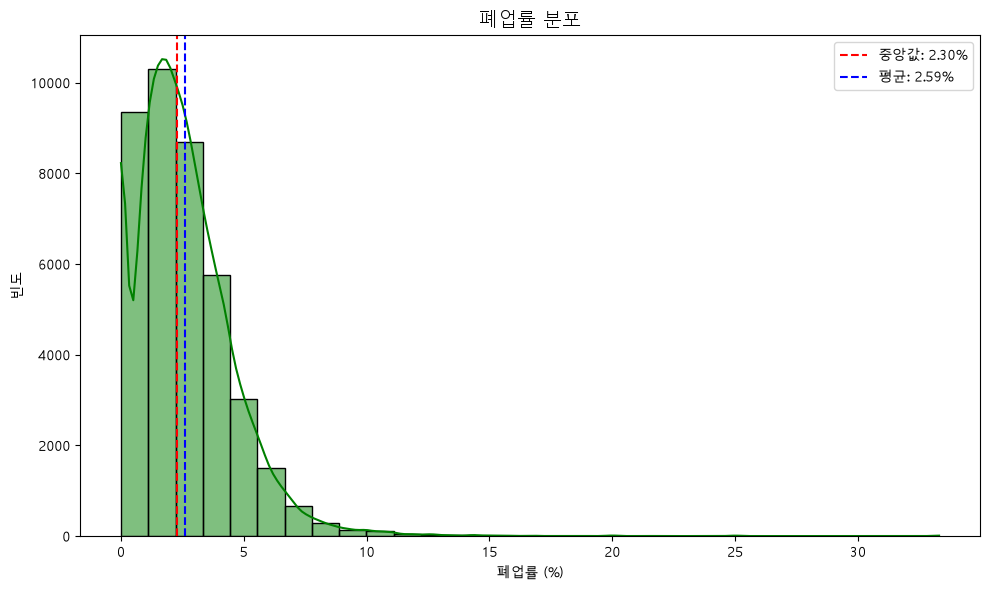

폐업률 통계:
  평균: 2.59%
  중앙값: 2.30%
  최대값: 33.30%
  표준편차: 2.00%


In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['폐업_률'], bins=30, kde=True, color='green')
plt.title('폐업률 분포', fontsize=14)
plt.xlabel('폐업률 (%)')
plt.ylabel('빈도')
plt.axvline(df['폐업_률'].median(), color='red', linestyle='--', label=f"중앙값: {df['폐업_률'].median():.2f}%")
plt.axvline(df['폐업_률'].mean(), color='blue', linestyle='--', label=f"평균: {df['폐업_률'].mean():.2f}%")
plt.legend()
plt.tight_layout()
plt.show()

print(f"폐업률 통계:")
print(f"  평균: {df['폐업_률'].mean():.2f}%")
print(f"  중앙값: {df['폐업_률'].median():.2f}%")
print(f"  최대값: {df['폐업_률'].max():.2f}%")
print(f"  표준편차: {df['폐업_률'].std():.2f}%")

### 인사이트
- 폐업률은 **오른쪽으로 치우친 (right-skewed) 분포**를 보임
- 대부분의 값이 0~5% 구간에 집중, 일부 극단값 존재 (최대 33.3%)
- 평균(약 2.59%) < 최대값 → 극단적인 우측 꼬리(long-tail) 분포
- 이러한 비대칭 분포는 **회귀 모델의 일반화 성능을 저하**시킴 → 추후 분류 문제로 전환 결정의 근거

## 3. 업종별 폐업률 분석

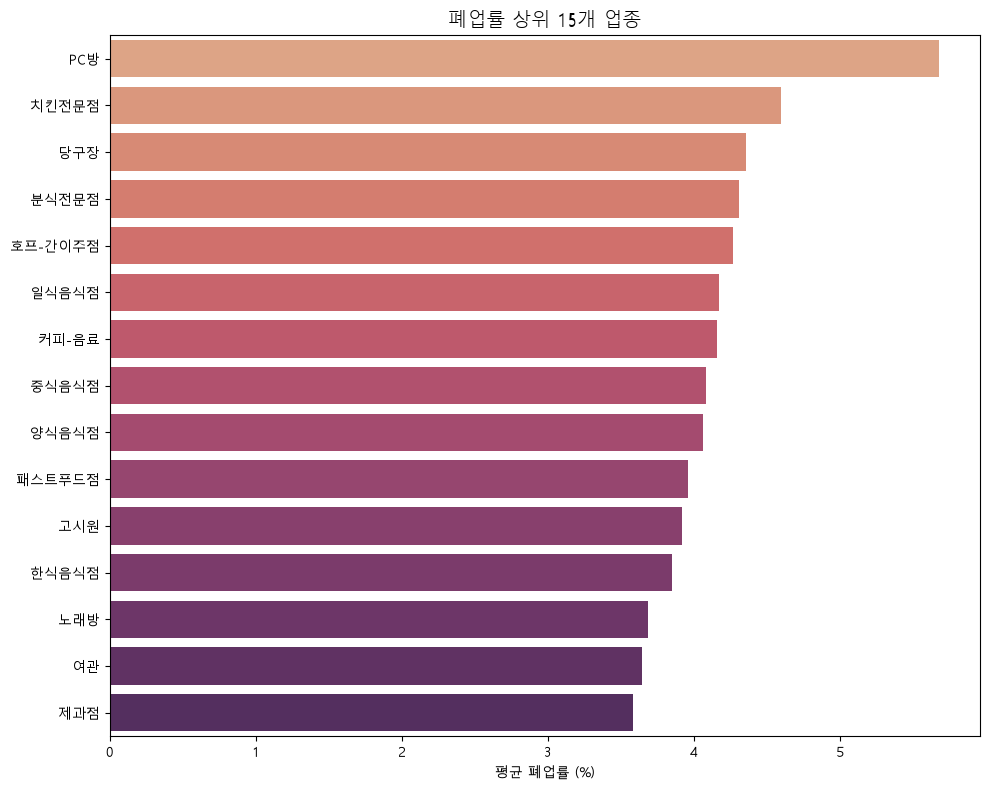

In [10]:
# 업종별 평균 폐업률 상위 15개
service_mean = df.groupby('서비스_업종_코드_명')['폐업_률'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=service_mean.values, y=service_mean.index, hue=service_mean.index, palette='flare', legend=False)
plt.title('폐업률 상위 15개 업종', fontsize=14)
plt.xlabel('평균 폐업률 (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 인사이트
- 특정 업종(호프/간이주점, 여관 등)이 높은 폐업률을 보임
- **업종**은 폐업률 예측에 중요한 피처가 될 것으로 예상

## 4. 상관관계 분석 (폐업률 기준 상위 10개)

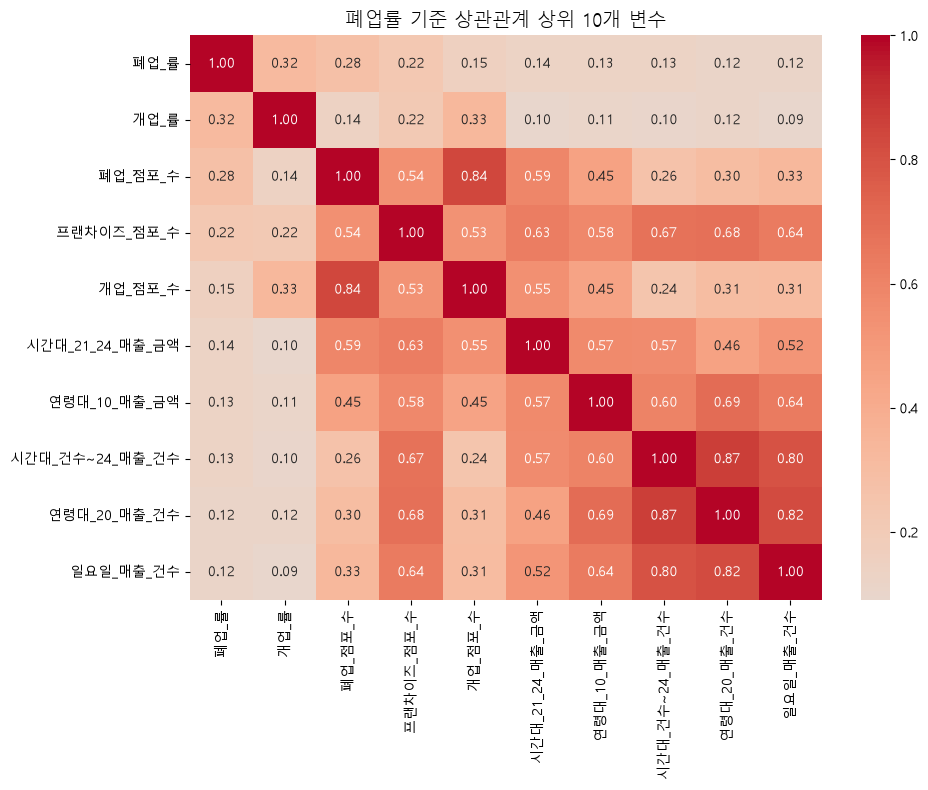

In [11]:
# 수치형 컬럼만 선택하여 상관관계 계산
corr = df.select_dtypes(include=[np.number]).corr()

# 폐업률과의 상관관계 절댓값 기준 상위 10개 추출
if '폐업_률' in corr.columns:
    target_corr = corr['폐업_률'].dropna()
    top_features = target_corr.abs().sort_values(ascending=False).head(10).index

    corr_subset = corr.loc[top_features, top_features]
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('폐업률 기준 상관관계 상위 10개 변수', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('폐업_률 컬럼이 없습니다. merged_data를 사용하세요.')

## 5. 프랜차이즈 비율 vs 폐업 위험도

프랜차이즈 점포 비율이 높을수록 폐업률이 증가하는 경향이 있는지 확인합니다.

C:\Users\wnsgu\AppData\Local\Temp\ipykernel_30688\1898979376.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['폐업_위험'] = (df['폐업_률'] > threshold).astype(int)
C:\Users\wnsgu\AppData\Local\Temp\ipykernel_30688\1898979376.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['프랜차이즈_비율'] = df['프랜차이즈_점포_수'] / df['유사_업종_점포_수']


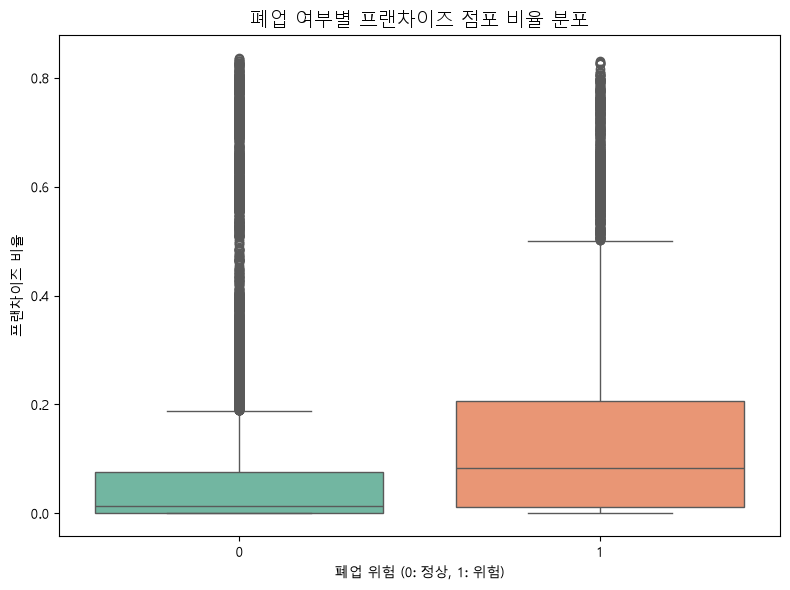

In [ ]:
# 폐업률 상위 25% 기준으로 위험 그룹 분류
threshold = df['폐업_률'].quantile(0.75)
df['폐업_위험'] = (df['폐업_률'] > threshold).astype(int)

# 프랜차이즈 비율 계산
df['프랜차이즈_비율'] = df['프랜차이즈_점포_수'] / df['유사_업종_점포_수']
df['프랜차이즈_비율'] = df['프랜차이즈_비율'].clip(upper=1)  # 1 초과값 제한

plt.figure(figsize=(8, 6))
sns.boxplot(x='폐업_위험', y='프랜차이즈_비율', data=df, hue='폐업_위험', palette='Set2', legend=False)
plt.title('폐업 여부별 프랜차이즈 점포 비율 분포', fontsize=14)
plt.xlabel('폐업 위험 (0: 정상, 1: 위험)')
plt.ylabel('프랜차이즈 비율')
plt.tight_layout()
plt.show()

### 인사이트
- 위험 그룹(1)은 전체 데이터의 25%에 불과하지만, 프랜차이즈 점포 수가 상대적으로 높음
- **프랜차이즈 점포 수가 많을수록 폐업률이 증가하는 경향** 확인
- 이는 프랜차이즈 경쟁이 치열한 업종일수록 폐업 위험이 높다는 것을 시사

## 6. EDA 결론 및 전처리 방향

### 주요 발견
1. **폐업률 분포**: 오른쪽으로 치우친 비대칭 분포 → 회귀 모델 적용 어려움
2. **업종별 차이**: 업종에 따라 폐업률 차이가 극심함 → 업종은 핵심 피처
3. **상관관계**: 개업률, 점포 수, 프랜차이즈 비율 등이 폐업률과 관련
4. **프랜차이즈 효과**: 프랜차이즈 비율이 높을수록 폐업 위험 증가

### 전처리 방향 결정
- **Drop**: 폐업_점포_수 (타겟 누수), 폐업_영업_개월_평균 (이미 폐업한 점포 정보)
- **Encoding**: 범주형 변수(자치구, 업종, 상권변화지표)에 Label Encoding
- **Feature Engineering**: Lag 피처, 변화율, 비율 피처 생성
- **Target 변환**: 폐업률 중앙값 기준 이진 분류로 전환

→ 다음 노트북 `02_preprocessing.ipynb`에서 상세 전처리 수행